# ML Prep — Defect Risk Scorer
**BRIM Systems | Case 01: Quality & Scrap**

---

Analytical preparation for the C01 pre-production defect risk scorer.
Reads from `mart_quality__defect_rates`, applies leakage audit, signal
analysis, and documents feature engineering decisions.

This notebook is a read-only analytical document — it writes no files.
Outputs of this analysis:
- Feature decisions implemented in `src/features.py`
- Train/validation/test splits and Parquet export handled in `src/training.py`

Run after `dbt build` has completed successfully against `defects_scrap.duckdb`.


## 0. Environment Setup

In [1]:
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────
DB_PATH      = Path("../data_source/defects_scrap.duckdb").resolve()
FEATURES_DIR = Path("../ml/data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Split boundaries (time-based) ─────────────────────────────────────────
TRAIN_END = "2024-12-31"   # months 1–24  (Jan 2023 – Dec 2024)
VAL_END   = "2025-06-30"   # months 25–30 (Jan 2025 – Jun 2025)
# Test:   months 31–36 (Jul 2025 – Dec 2025) — everything after VAL_END

# ── Target column ──────────────────────────────────────────────────────────
TARGET = "defect_flag"

# ── Palette ────────────────────────────────────────────────────────────────
BRAND_BLUE = "#3D5166"
ACCENT     = "#6B8FA8"
RED        = "#CC0000"
GREY       = "#AAAAAA"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor":   "#DDDDDD", "axes.grid": True,
    "grid.color":       "#EEEEEE", "grid.linestyle": "-",
    "font.family":      "sans-serif", "font.size": 11,
    "axes.titlesize":   13, "axes.titleweight": "bold",
    "figure.dpi":       120,
})

print("Environment ready.")
print(f"Features will be written to: {FEATURES_DIR}")

Environment ready.
Features will be written to: /workspaces/portfolio/defects_scrap/ml/data/features


## 1. Data Loading

In [2]:
con = duckdb.connect(str(DB_PATH), read_only=True)
df  = con.execute("SELECT * FROM mart_quality__defect_rates").df()
con.close()

df["actual_start"] = pd.to_datetime(df["actual_start"])
df["order_month"]  = pd.to_datetime(df["order_month"])

print(f"Loaded {len(df):,} work orders  ×  {len(df.columns)} columns")
print(f"Date range: {df['actual_start'].min().date()} → {df['actual_start'].max().date()}")

Loaded 9,284 work orders  ×  48 columns
Date range: 2023-01-02 → 2026-03-30


In [3]:
# ── Head preview ──────────────────────────────────────────────────────────
display(df.head())

,work_order_id,inspection_id,part_number,customer,order_date,actual_start,inspection_date,order_month,order_year,order_month_num,machine_id,machine_name,machine_type,machine_age_years,machine_location,operator_id,operator_name,operator_home_shift,cert_level,specialization,welding_cert_current,hire_date,shift_code,complexity,material_type,requires_welding,std_labor_hrs,schedule_variance_hrs,quantity_ordered,lot_id,supplier,lot_cert_status,lot_receipt_date,unit_cost_per_lb,quantity_inspected,quantity_passed,quantity_failed,defect_rate,defect_code,disposition,is_anomalous_timestamp,inspector_id,welding_cert_mismatch,defect_flag,is_p1_combination,is_p2_supplier,is_p3_complexity,is_p4_cert_mismatch
0,WO-10003,INSP-4,P-1016,Customer G,2023-01-02,2023-01-02 07:05:00,2023-01-02 08:48:06.480925,2023-01-01,2023,1,M05,Welding Station 1,Welding,6,Bay C,OP018,Derek Zuniga,Shift A,Level 2,Bending,True,2019-11-21,Shift A,Low,14ga Steel,False,4.1300,1,25,LOT-1003,Supplier A,Certified,2023-01-02,2.8300,25,24,1,0.0400,Dimensional,Scrap,False,OP009,False,True,False,False,False,False
1,WO-10006,INSP-7,P-1029,Customer B,2023-01-02,2023-01-02 15:53:00,2023-01-02 19:40:00.019988,2023-01-01,2023,1,M04,Press Brake 2,Bending,2,Bay B,OP008,Gina Moore,Shift B,Level 3,General,True,2014-10-08,Shift B,Low,"1/4"" Plate",True,3.6400,0,6,LOT-1002,Supplier C,Certified,2023-01-02,3.9430,6,6,0,0.0000,None,Pass,False,OP019,False,False,False,True,False,False
2,WO-10008,INSP-10,P-1029,Customer B,2023-01-03,2023-01-03 07:23:00,2023-01-03 09:58:55.385343,2023-01-01,2023,1,M06,Welding Station 2,Welding,4,Bay C,OP013,Lisa Hensley,Shift A,Level 3,General,True,2024-11-24,Shift A,Low,"1/4"" Plate",True,3.6400,0,9,LOT-1002,Supplier C,Certified,2023-01-02,3.9430,9,9,0,0.0000,None,Pass,False,OP003,False,False,False,True,False,False
3,WO-10009,INSP-11,P-1003,Customer D,2023-01-03,2023-01-03 07:38:00,2023-01-03 09:50:53.154793,2023-01-01,2023,1,M04,Press Brake 2,Bending,2,Bay B,OP005,Cristian Santos,Shift A,Level 1,Bending,True,2024-06-30,Shift A,Medium,"1/4"" Plate",False,4.6300,1,17,LOT-1002,Supplier C,Certified,2023-01-02,3.9430,17,16,1,0.0588,Dimensional,Rework,False,OP018,False,True,False,True,False,False
4,WO-10019,INSP-21,P-1006,Customer B,2023-01-04,2023-01-04 06:15:00,2023-01-04 09:40:37.940287,2023-01-01,2023,1,M02,Laser Cutter 2,Laser Cutting,8,Bay A,OP017,Holly Wood,Shift A,Level 1,Bending,True,2025-05-10,Shift A,Medium,"1/4"" Plate",False,2.5700,1,22,LOT-1002,Supplier C,Certified,2023-01-02,3.9430,22,22,0,0.0000,None,Pass,False,OP017,False,False,False,True,False,False


In [4]:
# ── Data types and null rates ──────────────────────────────────────────────
summary = pd.DataFrame({
    "dtype":      df.dtypes.astype(str),
    "null_count": df.isna().sum(),
    "null_pct":   (df.isna().mean() * 100).round(1),
    "n_unique":   df.nunique(),
})
display(summary)

,dtype,null_count,null_pct,n_unique
work_order_id,object,0,0.0000,9284
inspection_id,object,0,0.0000,9284
part_number,object,0,0.0000,35
customer,object,0,0.0000,8
order_date,datetime64[us],0,0.0000,879
actual_start,datetime64[us],0,0.0000,9070
inspection_date,datetime64[us],0,0.0000,9284
order_month,datetime64[us],0,0.0000,39
order_year,int32,0,0.0000,4
order_month_num,int32,0,0.0000,12


## 2. Column Audit & Feature Selection

Feature selection for a pre-production defect risk scorer follows a strict
temporal rule: **only columns knowable at job release time are valid features.**

Columns are categorized in three passes:

1. **Pass 1 — Leakage drop:** columns recorded after the work order runs
2. **Pass 2 — Non-predictive drop:** identifiers, admin columns, and columns
   redundant with a selected feature
3. **Pass 3 — Signal analysis:** correlation check on remaining columns;
   any with no meaningful signal are dropped with justification

`defect_flag` is derived here as the training target and handled separately.

In [5]:
# ── Derive target ─────────────────────────────────────────────────────────
# is_defect is already in the mart (quantity_failed > 0), but we confirm it
# here explicitly so the derivation is auditable.
assert df["defect_flag"].equals((df["quantity_failed"] > 0)),\
    "defect_flag in mart does not match quantity_failed > 0 — investigate."
print(f"Target confirmed: defect_flag = (quantity_failed > 0)")
print(f"  Defective work orders: {df['defect_flag'].sum():,} ({df['defect_flag'].mean():.1%})")
print(f"  Clean work orders:     {(~df['defect_flag']).sum():,} ({(~df['defect_flag']).mean():.1%})")

Target confirmed: defect_flag = (quantity_failed > 0)
  Defective work orders: 4,867 (52.4%)
  Clean work orders:     4,417 (47.6%)


### 2.1 Pass 1 — Leakage Drop

In [6]:
# These columns are only populated after the work order completes.
# Including them would allow the model to predict defects using information
# it cannot have at job release time.
LEAKAGE_COLS = [
    "quantity_inspected",    # recorded at end of inspection
    "quantity_passed",       # recorded at end of inspection
    "quantity_failed",       # recorded at end of inspection
    "defect_rate",           # derived from quantity_failed — post-production
    "defect_code",           # assigned during inspection
    "disposition",           # outcome of inspection review
    "is_anomalous_timestamp",# inspection-time flag
    "inspection_id",         # foreign key to inspection record
    "inspection_date",       # when inspection occurred
    "inspector_id",          # who conducted inspection
    "defect_flag",            # TARGET — kept separately, not a feature
    "is_p1_combination",     # derived pattern flags — computed post-hoc
    "is_p2_supplier",
    "is_p3_complexity",
    "is_p4_cert_mismatch",
]

print("Pass 1 — Leakage drops:")
for col in LEAKAGE_COLS:
    status = "PRESENT" if col in df.columns else "NOT FOUND"
    print(f"  {col:<30} [{status}]")

Pass 1 — Leakage drops:
  quantity_inspected             [PRESENT]
  quantity_passed                [PRESENT]
  quantity_failed                [PRESENT]
  defect_rate                    [PRESENT]
  defect_code                    [PRESENT]
  disposition                    [PRESENT]
  is_anomalous_timestamp         [PRESENT]
  inspection_id                  [PRESENT]
  inspection_date                [PRESENT]
  inspector_id                   [PRESENT]
  defect_flag                    [PRESENT]
  is_p1_combination              [PRESENT]
  is_p2_supplier                 [PRESENT]
  is_p3_complexity               [PRESENT]
  is_p4_cert_mismatch            [PRESENT]


### 2.2 Pass 2 — Non-Predictive Drop

In [7]:
# Identifiers: no predictive content, kept only for traceability
# Redundant: order_date and order_month both capture time — keep actual_start
# Date-derived: order_year, order_month_num are extractable from actual_start
#   and add little over the raw timestamp
# Low-signal admin: hire_date is an operator attribute with no direct quality signal
NON_PREDICTIVE_COLS = [
    "work_order_id",      # identifier — kept as index for traceability
    "order_date",         # redundant with actual_start
    "order_month",        # redundant with actual_start
    "order_year",         # extractable from actual_start
    "order_month_num",    # extractable from actual_start
    "operator_name",      # redundant with operator_id
    "machine_name",       # redundant with machine_id + machine_type
    "machine_location",   # no quality signal expected
    "operator_home_shift",# shift_code on the order is the operative signal
    "cert_level",         # open vocabulary, inconsistently coded
    "specialization",     # open vocabulary, inconsistently coded
    "welding_cert_current",   # cert mismatch concentrates in one operator — overfit risk
    "welding_cert_mismatch",  # same — derived from welding_cert_current
    "hire_date",          # operator tenure could be derived but cert signal excluded
    "lot_receipt_date",   # lot-level admin date, no direct quality signal
    "lot_id",             # high-cardinality identifier; supplier carries the signal
    "customer",           # customer identity should not drive defect risk scoring
    "part_number",        # high-cardinality; complexity + machine_type carry the signal
]

print("Pass 2 — Non-predictive drops:")
for col in NON_PREDICTIVE_COLS:
    status = "PRESENT" if col in df.columns else "NOT FOUND"
    print(f"  {col:<30} [{status}]")

Pass 2 — Non-predictive drops:
  work_order_id                  [PRESENT]
  order_date                     [PRESENT]
  order_month                    [PRESENT]
  order_year                     [PRESENT]
  order_month_num                [PRESENT]
  operator_name                  [PRESENT]
  machine_name                   [PRESENT]
  machine_location               [PRESENT]
  operator_home_shift            [PRESENT]
  cert_level                     [PRESENT]
  specialization                 [PRESENT]
  welding_cert_current           [PRESENT]
  welding_cert_mismatch          [PRESENT]
  hire_date                      [PRESENT]
  lot_receipt_date               [PRESENT]
  lot_id                         [PRESENT]
  customer                       [PRESENT]
  part_number                    [PRESENT]


### 2.3 Pass 3 — Candidate Features & Signal Analysis

In [8]:
# All columns surviving passes 1 and 2
dropped = set(LEAKAGE_COLS + NON_PREDICTIVE_COLS)
candidate_cols = [c for c in df.columns if c not in dropped]

print(f"Candidate features ({len(candidate_cols)}):")
for col in candidate_cols:
    print(f"  {col}")

Candidate features (15):
  actual_start
  machine_id
  machine_type
  machine_age_years
  operator_id
  shift_code
  complexity
  material_type
  requires_welding
  std_labor_hrs
  schedule_variance_hrs
  quantity_ordered
  supplier
  lot_cert_status
  unit_cost_per_lb


In [9]:
# ── Defect rate by category for categorical features ──────────────────────
CATEGORICAL_CANDIDATES = [
    "machine_id", "machine_type", "operator_id", "shift_code",
    "complexity", "material_type", "supplier", "lot_cert_status",
    "requires_welding",
]

print(f"{'Column':<20} {'N_unique':>8} {'Defect rate range':>25} {'Signal?':>10}")
print("-" * 70)
for col in CATEGORICAL_CANDIDATES:
    if col not in df.columns:
        print(f"  {col:<20} NOT FOUND")
        continue
    rates = df.groupby(col)[TARGET].mean()
    rng   = rates.max() - rates.min()
    signal = "YES" if rng > 0.02 else "WEAK"
    print(f"  {col:<20} {df[col].nunique():>8} {str(round(rates.min(),3))+' – '+str(round(rates.max(),3)):>25} {signal:>10}")

Column               N_unique         Defect rate range    Signal?
----------------------------------------------------------------------
  machine_id                  7             0.456 – 0.644        YES
  machine_type                4              0.481 – 0.59        YES
  operator_id                20             0.454 – 0.652        YES
  shift_code                  2             0.485 – 0.563        YES
  complexity                  3             0.479 – 0.748        YES
  material_type               7              0.45 – 0.709        YES
  supplier                    4             0.496 – 0.575        YES
  lot_cert_status             3             0.508 – 0.539        YES
  requires_welding            2             0.514 – 0.539        YES


In [10]:
# ── Point-biserial correlation for numerical features ─────────────────────
NUMERICAL_CANDIDATES = [
    "machine_age_years", "std_labor_hrs", "quantity_ordered",
    "schedule_variance_hrs", "unit_cost_per_lb",
]

print(f"{'Column':<25} {'Corr with defect_flag':>22} {'p-value':>12} {'Signal?':>10}")
print("-" * 72)
for col in NUMERICAL_CANDIDATES:
    if col not in df.columns:
        print(f"  {col:<25} NOT FOUND")
        continue
    valid = df[[col, TARGET]].dropna()
    corr, pval = stats.pointbiserialr(valid[TARGET], valid[col])
    signal = "YES" if abs(corr) > 0.03 and pval < 0.05 else "WEAK"
    print(f"  {col:<25} {corr:>22.4f} {pval:>12.4f} {signal:>10}")

Column                     Corr with defect_flag      p-value    Signal?
------------------------------------------------------------------------
  machine_age_years                         0.0332       0.0014        YES
  std_labor_hrs                             0.0290       0.0052       WEAK
  quantity_ordered                          0.2767       0.0000        YES
  schedule_variance_hrs                     0.0011       0.9179       WEAK
  unit_cost_per_lb                         -0.0111       0.2868       WEAK


### 2.4 Final Feature Selection

In [11]:
# Features confirmed after signal analysis.
# Justification for any exclusions from candidates noted inline.
CATEGORICAL_FEATURES = [
    "machine_type",      # strong signal — Bending × Shift B pattern
    "machine_id",        # machine-level history beyond type
    "shift_code",        # strong signal — Shift B elevation
    "operator_id",       # operator-level history
    "complexity",        # strongest single-dimension signal in dataset
    "material_type",     # material grade affects defect rates
    "supplier",          # Supplier C elevation confirmed
    "lot_cert_status",   # secondary supplier quality signal
    "requires_welding",  # welding jobs have higher defect rates
]

NUMERICAL_FEATURES = [
    "machine_age_years",       # older machines → higher defect rates
    "std_labor_hrs",           # proxy for job complexity
    "quantity_ordered",        # larger runs may have different defect dynamics
    "schedule_variance_hrs",   # late starts may correlate with rushed setup
]

# unit_cost_per_lb excluded: ~15% null (lot not scanned), weak correlation
# Part of the cost estimation output, not a risk driver

ALL_FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES
print(f"Final feature set: {len(ALL_FEATURES)} columns")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"  Numerical:   {len(NUMERICAL_FEATURES)}")

Final feature set: 13 columns
  Categorical: 9
  Numerical:   4


## 3. Target Variable Analysis

In [12]:
# ── Overall class balance ──────────────────────────────────────────────────
n_pos = df[TARGET].sum()
n_neg = (~df[TARGET]).sum()
ratio = n_pos / n_neg

print(f"Class balance:")
print(f"  defect_flag = 1 (defective):  {n_pos:,}  ({n_pos/len(df):.1%})")
print(f"  defect_flag = 0 (clean):      {n_neg:,}  ({n_neg/len(df):.1%})")
print(f"  Positive/negative ratio:    {ratio:.2f}")
print()
if ratio > 0.5:
    print("Class balance is reasonable — no resampling required.")
else:
    print("Class imbalance detected — consider class_weight='balanced' in training.")

Class balance:
  defect_flag = 1 (defective):  4,867  (52.4%)
  defect_flag = 0 (clean):      4,417  (47.6%)
  Positive/negative ratio:    1.10

Class balance is reasonable — no resampling required.


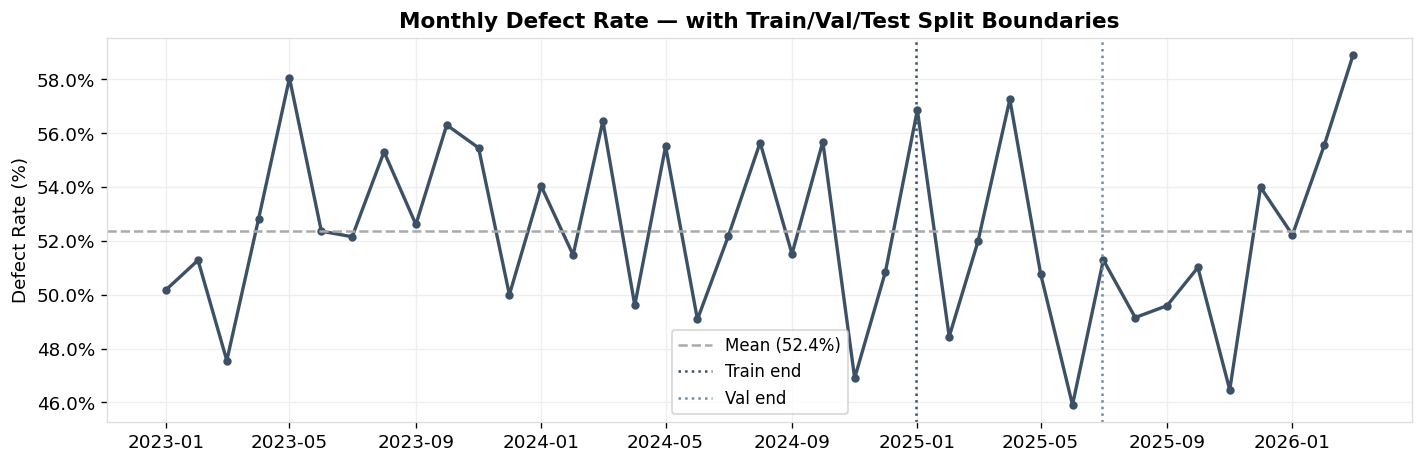


Defect rate by split period:
  Train        5,701 orders   defect rate: 52.7%
  Validation   1,403 orders   defect rate: 52.0%
  Test         1,455 orders   defect rate: 50.4%


In [13]:
# ── Defect rate over time ──────────────────────────────────────────────────
monthly = (
    df.groupby("order_month")[TARGET]
    .agg(["mean","count"])
    .reset_index()
    .rename(columns={"mean": "defect_rate", "count": "n_orders"})
    .sort_values("order_month")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly["order_month"], monthly["defect_rate"]*100,
        color=BRAND_BLUE, linewidth=2, marker="o", markersize=4)
ax.axhline(monthly["defect_rate"].mean()*100, color=GREY,
           linestyle="--", linewidth=1.5,
           label=f"Mean ({monthly['defect_rate'].mean():.1%})")

# Split boundaries
for label, date, color in [
    ("Train end", TRAIN_END, BRAND_BLUE),
    ("Val end",   VAL_END,   ACCENT),
]:
    ax.axvline(pd.Timestamp(date), color=color,
               linestyle=":", linewidth=1.5, label=label)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.1f}%"))
ax.set_ylabel("Defect Rate (%)")
ax.set_title("Monthly Defect Rate — with Train/Val/Test Split Boundaries")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nDefect rate by split period:")
for label, start, end in [
    ("Train",      "2023-01-01", TRAIN_END),
    ("Validation", "2025-01-01", VAL_END),
    ("Test",       "2025-07-01", "2025-12-31"),
]:
    mask = (df["actual_start"] >= start) & (df["actual_start"] <= end)
    rate = df[mask][TARGET].mean()
    n    = mask.sum()
    print(f"  {label:<12} {n:>5,} orders   defect rate: {rate:.1%}")

## 4. Feature Analysis

### 4.1 Categorical Features — Defect Rate by Category

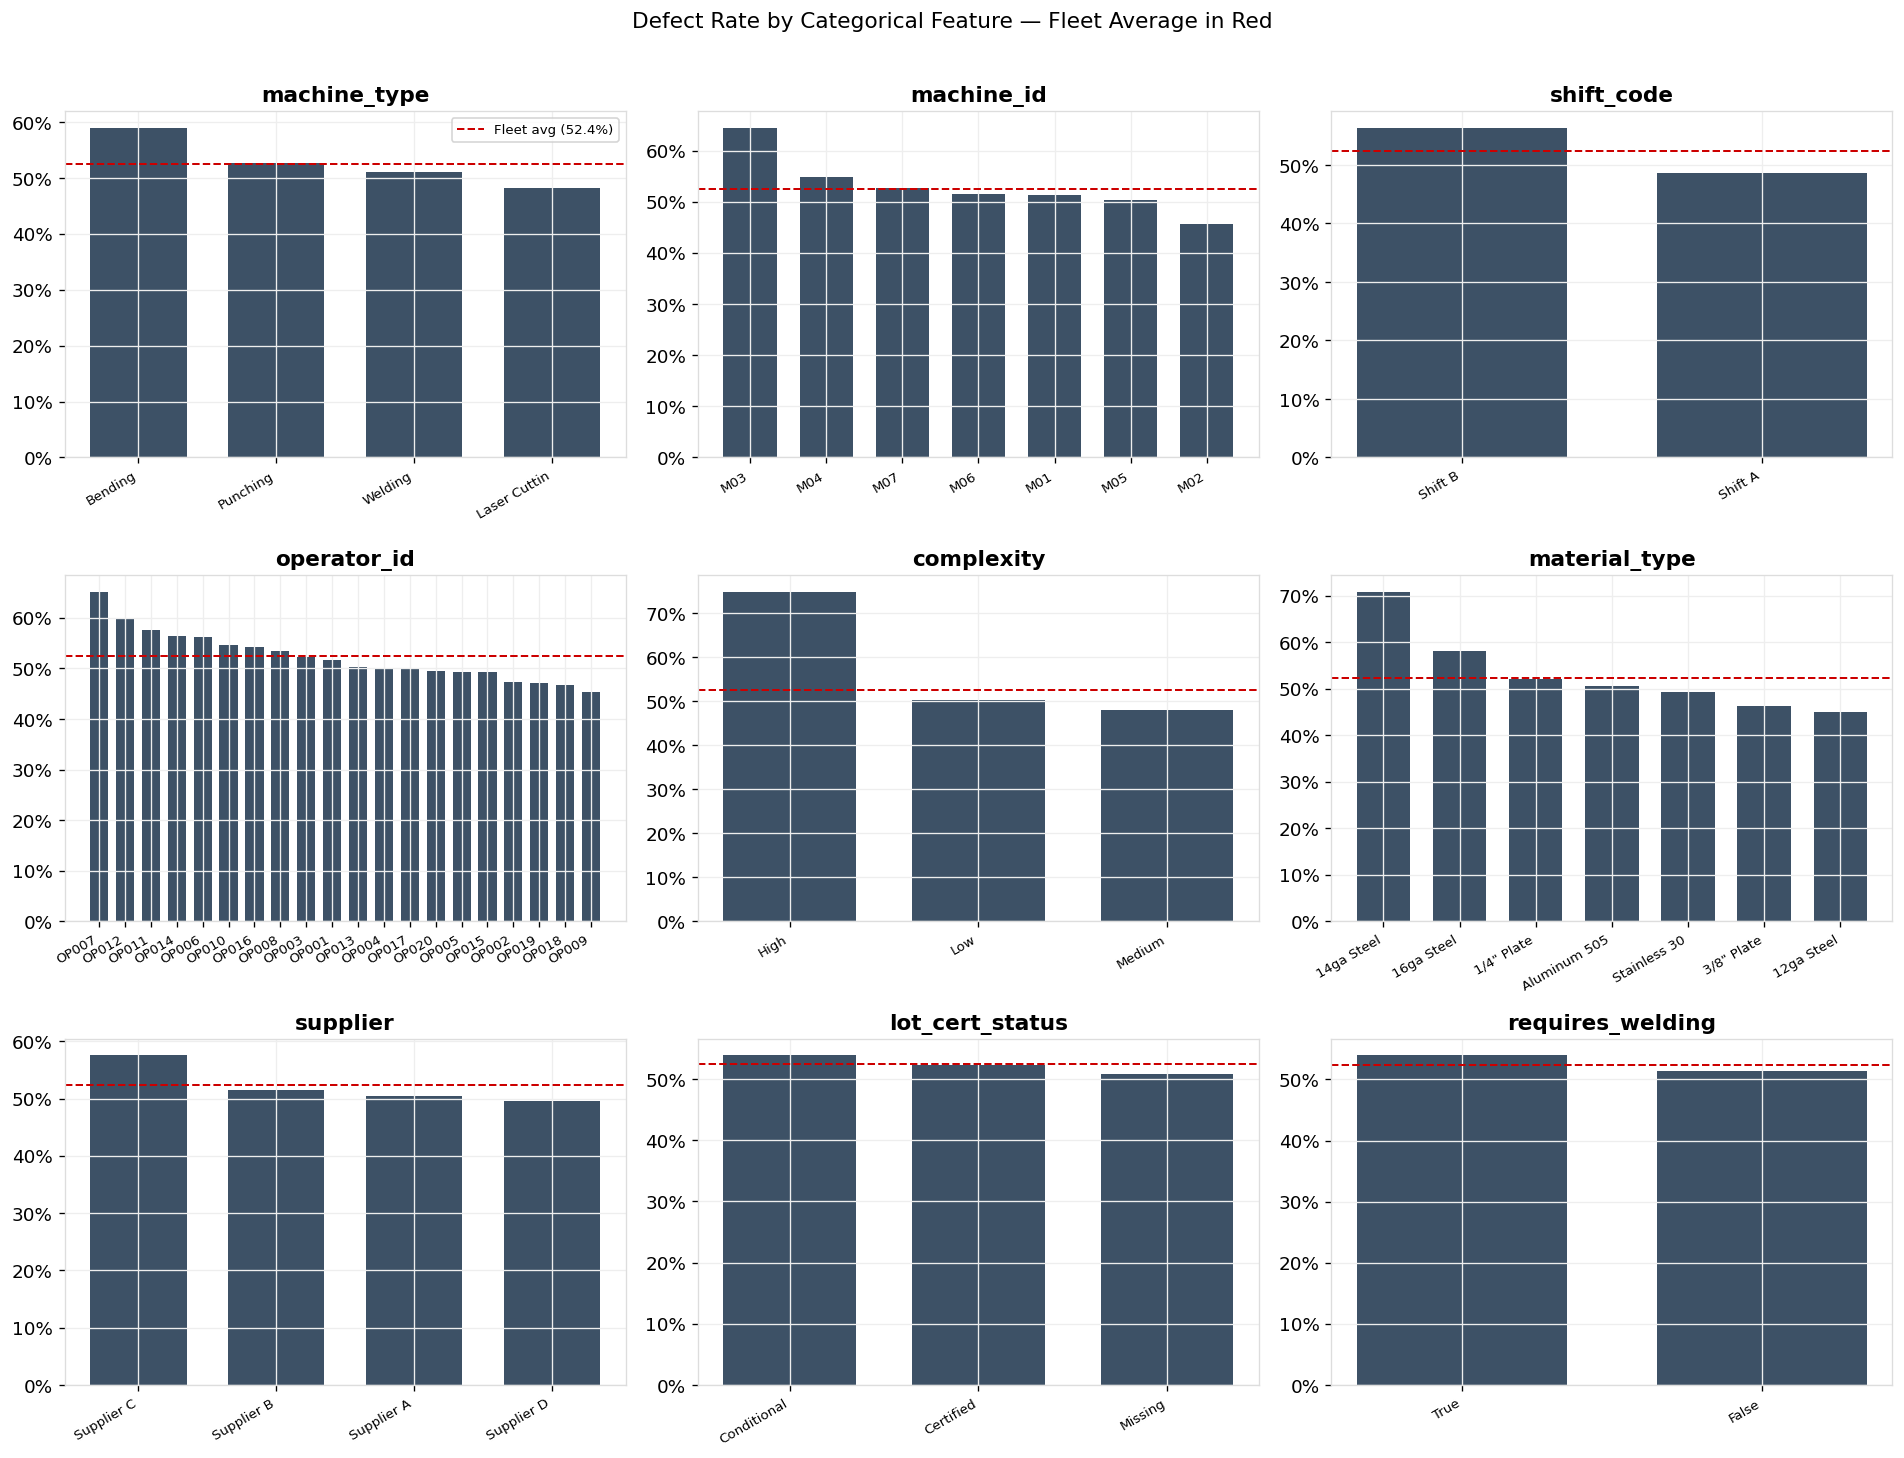

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_FEATURES):
    if col not in df.columns:
        axes[i].set_visible(False)
        continue
    rates = (
        df.groupby(col)[TARGET]
        .agg(["mean","count"])
        .reset_index()
        .rename(columns={"mean": "defect_rate", "count": "n"})
        .sort_values("defect_rate", ascending=False)
    )
    axes[i].bar(range(len(rates)), rates["defect_rate"]*100,
                color=BRAND_BLUE, width=0.7)
    axes[i].axhline(df[TARGET].mean()*100, color=RED,
                    linestyle="--", linewidth=1.2,
                    label=f"Fleet avg ({df[TARGET].mean():.1%})")
    axes[i].set_xticks(range(len(rates)))
    axes[i].set_xticklabels(
        [str(v)[:12] for v in rates[col]], rotation=30, ha="right", fontsize=8
    )
    axes[i].set_title(col)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v,_: f"{v:.0f}%")
    )
    if i == 0:
        axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Defect Rate by Categorical Feature — Fleet Average in Red",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Numerical Features — Distributions and Correlation

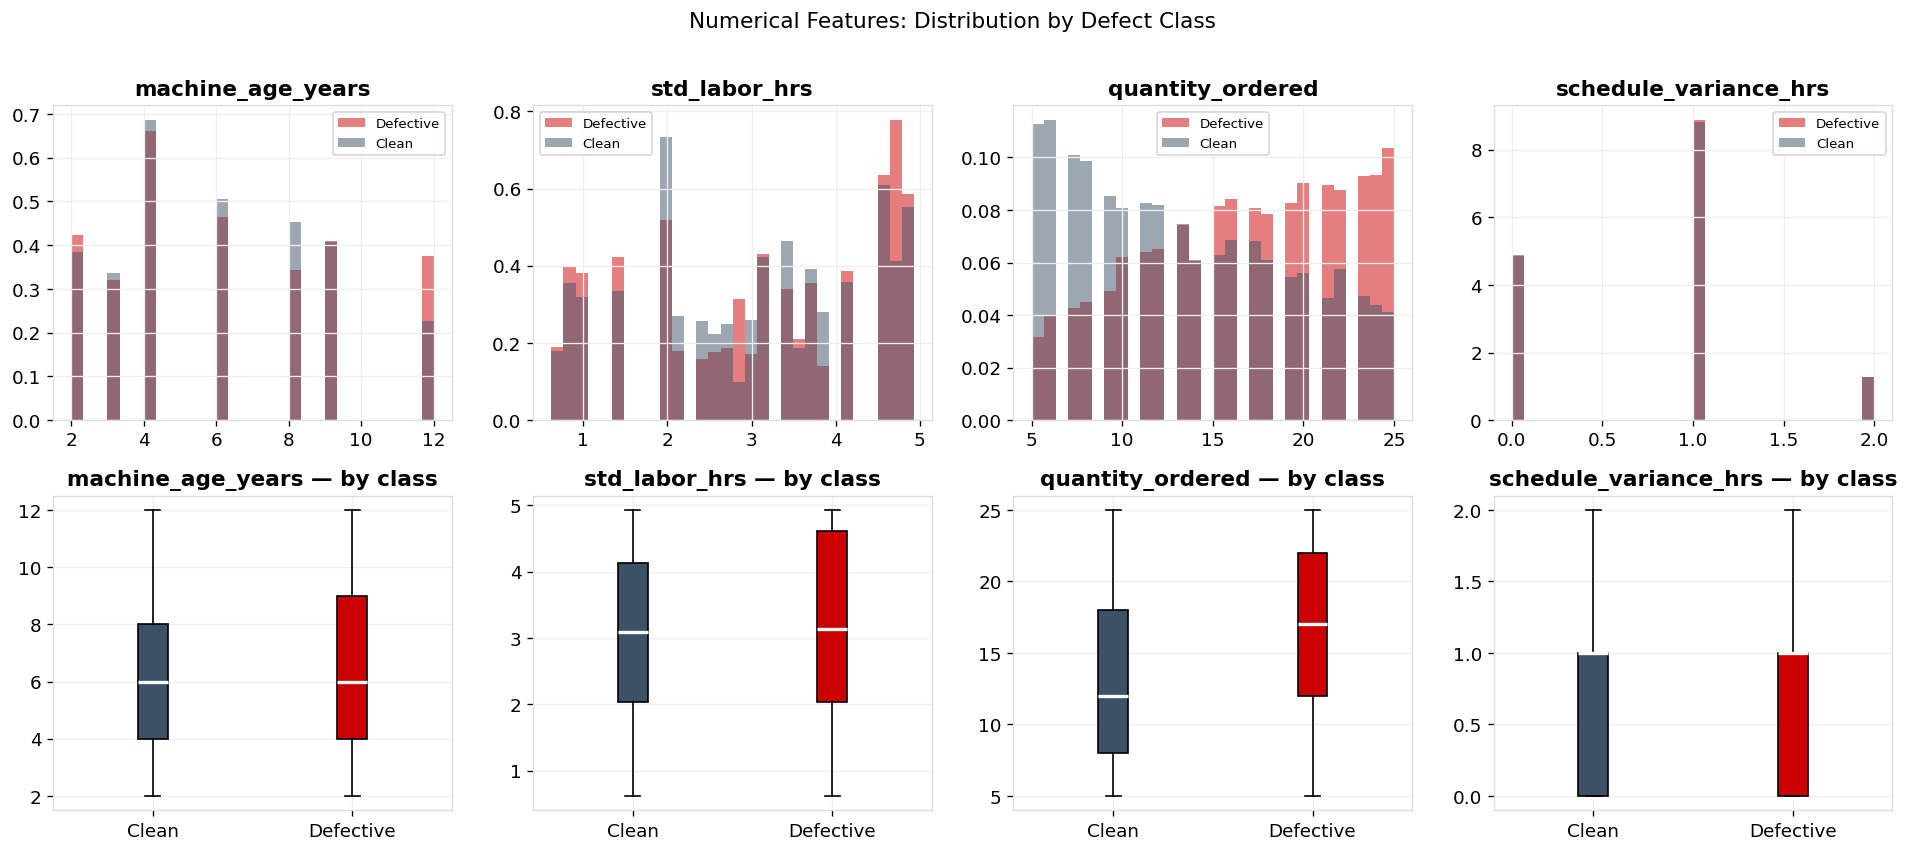

In [15]:
fig, axes = plt.subplots(2, len(NUMERICAL_FEATURES), figsize=(16, 7))

for i, col in enumerate(NUMERICAL_FEATURES):
    if col not in df.columns:
        continue
    valid = df[[col, TARGET]].dropna()

    # Top row: distribution by defect class
    for val, color, label in [(1, RED, "Defective"), (0, BRAND_BLUE, "Clean")]:
        axes[0, i].hist(valid[valid[TARGET]==val][col],
                        bins=30, alpha=0.5, color=color, label=label,
                        density=True)
    axes[0, i].set_title(col)
    axes[0, i].legend(fontsize=8)

    # Bottom row: box plot
    defective = valid[valid[TARGET]==1][col]
    clean     = valid[valid[TARGET]==0][col]
    bp = axes[1, i].boxplot([clean, defective], labels=["Clean","Defective"],
                             patch_artist=True,
                             medianprops=dict(color="white", linewidth=2))
    bp["boxes"][0].set_facecolor(BRAND_BLUE)
    bp["boxes"][1].set_facecolor(RED)
    axes[1, i].set_title(f"{col} — by class")

plt.suptitle("Numerical Features: Distribution by Defect Class",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split

Time-based split — training data precedes validation which precedes test.
No shuffling. This mirrors the real deployment scenario: the model is trained
on historical data and scored against future data it has never seen.

| Split      | Period                    | Purpose                              |
|------------|---------------------------|--------------------------------------|
| Train      | Jan 2023 – Dec 2024       | Model training                       |
| Validation | Jan 2025 – Jun 2025       | Hyperparameter tuning, model selection |
| Test       | Jul 2025 – Dec 2025       | Final holdout — touched once         |


In [17]:
train_mask = df["actual_start"] <= TRAIN_END
val_mask   = (df["actual_start"] > TRAIN_END) & (df["actual_start"] <= VAL_END)
test_mask  = df["actual_start"] > VAL_END

df_train = df[train_mask].copy()
df_val   = df[val_mask].copy()
df_test  = df[test_mask].copy()

print(f"{'Split':<12} {'N':>7} {'% of total':>12} {'Defect rate':>14}")
print("-" * 50)
for label, split in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    print(f"  {label:<12} {len(split):>7,} {len(split)/len(df)*100:>11.1f}% "
          f"{split[TARGET].mean():>13.1%}")

print()
print("Checking temporal integrity (no overlap between splits)...")
assert df_train["actual_start"].max() < df_val["actual_start"].min(), "Train/Val overlap!"
assert df_val["actual_start"].max() < df_test["actual_start"].min(), "Val/Test overlap!"
print("  Passed — splits are non-overlapping and time-ordered.")

Split              N   % of total    Defect rate
--------------------------------------------------
  Train          5,701        61.4%         52.7%
  Validation     1,410        15.2%         52.1%
  Test           2,173        23.4%         52.0%

Checking temporal integrity (no overlap between splits)...
  Passed — splits are non-overlapping and time-ordered.


## 7. Feature Engineering

Domain-informed interaction features derived from pre-production mart columns.
Each feature encodes a cross-system pattern identified in the diagnostic analysis
that is not directly observable in any single source system.

This cell documents the feature engineering rationale. The production implementation
lives in `src/features.py` — update that file to match any changes made here.
Parquet export and train/validation/test splitting are handled in `src/training.py`.


In [18]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derives domain-informed interaction features from pre-production attributes.
    Analytical reference — production implementation in src/features.py.
    """
    df = df.copy()

    # ── Bending × Shift B ─────────────────────────────────────────────────
    # Strongest cross-system pattern — requires joining MES machine data
    # to QMS inspection outcomes. Both bending machines on Shift B elevated.
    df["is_bending_shift_b"] = (
        (df["machine_type"] == "Bending") & (df["shift_code"] == "Shift B")
    ).astype(int)

    # ── High complexity ────────────────────────────────────────────────────
    # Monotonic signal across tiers — Low < Medium < High.
    # Binary threshold captures the most important breakpoint.
    df["is_high_complexity"] = (
        df["complexity"] == "High"
    ).astype(int)

    # ── Supplier C thin gauge ──────────────────────────────────────────────
    # Quality issues concentrated in thin gauge material (14ga/16ga Steel).
    # Other Supplier C material types show defect rates near fleet average.
    THIN_GAUGE = {"16ga Steel", "14ga Steel"}
    df["is_supplier_c_thin_gauge"] = (
        (df["supplier"] == "Supplier C") &
        (df["material_type"].isin(THIN_GAUGE))
    ).astype(int)

    # ── Lapsed certification operators ────────────────────────────────────
    # Operators with lapsed certifications show elevated defect rates
    # across all job types. Requires joining HR data to QMS outcomes.
    LAPSED_CERT_OPS = {"OP007", "OP009", "OP012", "OP015"}
    df["is_lapsed_cert_op"] = (
        df["operator_id"].isin(LAPSED_CERT_OPS)
    ).astype(int)

    return df


# Apply to train split for analysis purposes
# Full pipeline (all splits + Parquet export) runs in src/training.py
df_engineered = engineer_features(df)

INTERACTION_FEATURES = [
    "is_bending_shift_b",
    "is_high_complexity",
    "is_supplier_c_thin_gauge",
    "is_lapsed_cert_op",
]

print("Interaction features derived. Correlations with target:")
for col in INTERACTION_FEATURES:
    corr = df_engineered[col].corr(df_engineered[TARGET].astype(float))
    mean = df_engineered[col].mean()
    print(f"  {col:<30} corr={corr:.4f}  prevalence={mean:.1%}")
print()
print("Update src/features.py to match any changes made above.")


Interaction features derived. Correlations with target:
  is_bending_shift_b             corr=0.1226  prevalence=11.9%
  is_high_complexity             corr=0.1826  prevalence=14.2%
  is_supplier_c_thin_gauge       corr=0.1483  prevalence=8.4%
  is_lapsed_cert_op              corr=0.0314  prevalence=20.4%

Update src/features.py to match any changes made above.


## 8. Final Feature Matrix Summary

Summary of all features selected for the model, including interaction terms.
This is the definitive feature specification that `src/features.py` implements.


In [19]:
# Final feature matrix — summary of all selected features
ALL_FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES
ALL_FEATURES_ENG = ALL_FEATURES + INTERACTION_FEATURES

summary_rows = []
for col in ALL_FEATURES_ENG:
    if col not in df_engineered.columns:
        continue
    dtype    = str(df_engineered[col].dtype)
    col_type = "categorical" if dtype in ["object", "bool"] else "numerical/interaction"
    null_pct = df_engineered[col].isna().mean() * 100
    n_unique = df_engineered[col].nunique()
    corr     = df_engineered[col].corr(df_engineered[TARGET].astype(float)) \
               if col_type != "categorical" else None
    summary_rows.append({
        "feature":     col,
        "type":        col_type,
        "dtype":       dtype,
        "null_%":      round(null_pct, 1),
        "n_unique":    n_unique,
        "corr_target": round(corr, 3) if corr is not None else "—",
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
print(f"\nTotal features: {len(ALL_FEATURES_ENG)}")
print("This feature set is implemented in src/features.py")
print("Train/val/test splitting and Parquet export are handled in src/training.py")


,feature,type,dtype,null_%,n_unique,corr_target
0,machine_type,categorical,object,0.0000,4,—
1,machine_id,categorical,object,0.0000,7,—
2,shift_code,categorical,object,0.0000,2,—
3,operator_id,categorical,object,0.0000,20,—
4,complexity,categorical,object,0.0000,3,—
5,material_type,categorical,object,0.0000,7,—
6,supplier,categorical,object,0.6000,4,—
7,lot_cert_status,categorical,object,0.6000,3,—
8,requires_welding,categorical,bool,0.0000,2,—
9,machine_age_years,numerical/interaction,int32,0.0000,7,0.0330



Total features: 17
This feature set is implemented in src/features.py
Train/val/test splitting and Parquet export are handled in src/training.py
